In [2]:
# %matplotlib ipympl


import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import struct
import math
import time
import sys

sys.path.append('..')

import stressdrop_file_IO as sdio
import seismo_functions as sf
import mapping_tools as mt
import importlib
importlib.reload(sdio)
import obspy

from scipy import sparse
import utm
import copy 

import ipywidgets as widgets
from ipywidgets import interactive

from shapely.geometry import Point, MultiPoint
from shapely.geometry.polygon import Polygon

from lib.beta_functions import read_spec_df

from tqdm import trange

import matplotlib.patches as patches

In [3]:
def compute_logbeta(spectra, low_f_ind, high_f_ind):
    # spectra is an (N x nf) array
    low_band = np.median(np.log10(spectra[:, low_f_ind[0]:low_f_ind[1]+1]), axis=1)
    high_band = np.median(np.log10(spectra[:, high_f_ind[0]:high_f_ind[1]+1]), axis=1)
    logbeta = high_band - low_band
    return logbeta

Beta method depiction figure

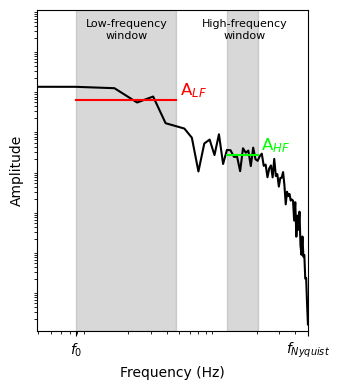

In [27]:


p_spec_dir = "/Users/ivandevert/projects/ridgecrest2019_prev/proc/spectral/01_compspec/SPECOUT/"

spec_files = [el for el in os.listdir(p_spec_dir) if el.endswith(".spec")]
spec_files.sort()

filename = spec_files[10]

spec = read_spec_df(p_spec_dir+filename)

ispec = 10

fn = 50.0
nf = 65
f = np.linspace(0, fn, nf)

low_beta_window = [1, 5]
high_beta_window = [12, 20]

low_beta_window_inds = np.array([np.argmin(np.abs(f - el)) for el in low_beta_window])
high_beta_window_inds = np.array([np.argmin(np.abs(f - el)) for el in high_beta_window])

s2 = spec['s2'][ispec]

low_band  = 10**(np.median(np.log10(s2[low_beta_window_inds[0]:low_beta_window_inds[1]+1])))
high_band = 10**(np.median(np.log10(s2[high_beta_window_inds[0]:high_beta_window_inds[1]+1])))

# low frequency range rectangle
low_rect = patches.Rectangle(
    (f[low_beta_window_inds[0]], 10E-11), 
    f[low_beta_window_inds[1]] - f[low_beta_window_inds[0]], 1,
    alpha=0.3, fill=True, color='gray')

high_rect = patches.Rectangle(
    (f[high_beta_window_inds[0]], 10E-11), 
    f[high_beta_window_inds[1]] - f[high_beta_window_inds[0]], 1,
    alpha=0.3, fill=True, color='gray'
)

lf_width = f[low_beta_window_inds[1]] - f[low_beta_window_inds[0]]
hf_width = f[high_beta_window_inds[1]] - f[high_beta_window_inds[0]]

log_lf_width = np.log10(f[low_beta_window_inds[1]]) - np.log10(f[low_beta_window_inds[0]])
log_hf_width = np.log10(f[high_beta_window_inds[1]]) - np.log10(f[high_beta_window_inds[0]])

fig = plt.figure(figsize=(3.5,4), layout='tight')
ax = plt.gca()
ax.plot(f, spec['s2'][ispec], label='P spectrum', c='k')

# plot median of low frequency window
ax.plot([f[low_beta_window_inds[0]], f[low_beta_window_inds[1]]], 
    [low_band, low_band], c='r')

# label the right end of this line with "A_{LF}"
ax.text(f[low_beta_window_inds[1]-1] + 10**(log_lf_width/2)* np.log10(3), 
    low_band, 'A$_{LF}$', ha='left', va='bottom', fontsize=12, color='r')

# plot median of high frequency window
ax.plot([f[high_beta_window_inds[0]], f[high_beta_window_inds[1]]], 
    [high_band, high_band], c='lime')

# label the right end of this line with "A_{HF}"
ax.text(f[high_beta_window_inds[1]+1] + 10**(log_hf_width/2)* np.log10(3), 
    high_band, 'A$_{HF}$', ha='left', va='bottom', fontsize=12, color='lime')


ax.add_patch(low_rect)
ax.add_patch(high_rect)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Amplitude')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim([f[1]/2, fn])
ax.set_ylim([1E-10, 1E-2])

ax.set_xticks([f[1], fn], labels=[r'$f_0$', r'$f_{Nyquist}$'], minor=False)
ax.set_yticks([], labels=[], minor=False)

# label the low and high beta windows at the top of the plot, inside the window, centered in the window



ax.text(f[low_beta_window_inds[0]] + 10**(log_lf_width/2)* np.log10(3), 
    10**-2.5, 'Low-frequency\nwindow', ha='center', va='center', fontsize=8, color='k')
ax.text((f[high_beta_window_inds[0]] + f[high_beta_window_inds[1]])/2, 
    10**-2.5, 'High-frequency\nwindow', ha='center', va='center', fontsize=8, color='k')


# plt.legend()
plt.savefig('windowing.pdf', bbox_inches='tight')
plt.show()


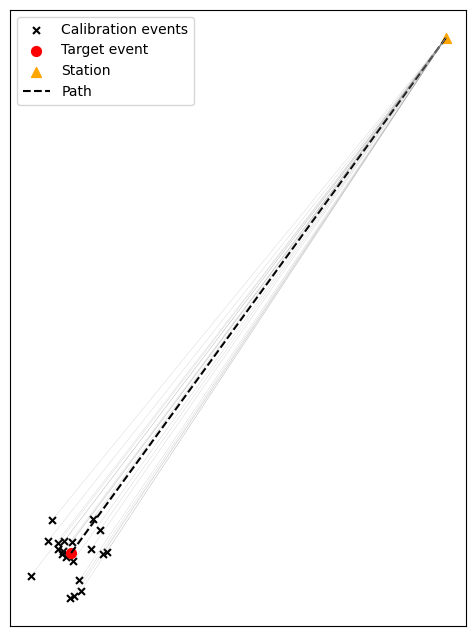

In [4]:
x_target = -5.0
y_target = -3.0

ncalib = 20
dmax_calib = 1.0

np.random.seed(42)

x_calib = np.random.uniform(0, dmax_calib, ncalib) * np.cos(np.random.uniform(0, np.pi*2, ncalib)) + x_target
y_calib = np.random.uniform(0, dmax_calib, ncalib) * np.sin(np.random.uniform(0, np.pi*2, ncalib)) + y_target

x_sta = 3.0
y_sta = 8.0

plt.figure(figsize=(8,8))
# plt.grid()

# plot events
plt.scatter(x_calib, y_calib, c='k', s=25, marker='x', label='Calibration events')
plt.scatter(x_target, y_target, c='r', s=50, marker='o', label='Target event')

# plot station with triangle marker
plt.scatter(x_sta, y_sta, c='orange', s=50, marker='^', label='Station')

# plot line from station to target event
plt.plot([x_target, x_sta], [y_target, y_sta], c='k', ls='--', label='Path')

# plot line from station to calibration events
for x, y in zip(x_calib, y_calib):
    plt.plot([x_sta, x], [y_sta, y], c='gray', ls='-', lw=0.1)

# plt.xlim((-10, 10))
# plt.ylim((-10, 10))

# remove axis labels and ticks
plt.xticks([])
plt.yticks([])

# set aspect ratio to 1:1
plt.gca().set_aspect('equal', adjustable='box')

plt.legend()
plt.savefig('calibration.pdf', bbox_inches='tight')

plt.show()


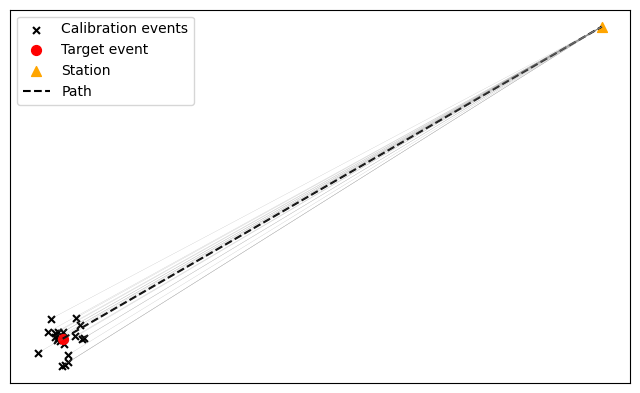

In [10]:
x_target = -5.0
y_target = -3.0

ncalib = 20
dmax_calib = 1.0

np.random.seed(42)

x_calib = np.random.uniform(0, dmax_calib, ncalib) * np.cos(np.random.uniform(0, np.pi*2, ncalib)) + x_target
y_calib = np.random.uniform(0, dmax_calib, ncalib) * np.sin(np.random.uniform(0, np.pi*2, ncalib)) + y_target

x_sta = 14.0
y_sta = 8.0

plt.figure(figsize=(8,8))
# plt.grid()

# plot events
plt.scatter(x_calib, y_calib, c='k', s=25, marker='x', label='Calibration events')
plt.scatter(x_target, y_target, c='r', s=50, marker='o', label='Target event')

# plot station with triangle marker
plt.scatter(x_sta, y_sta, c='orange', s=50, marker='^', label='Station')

# plot line from station to target event
plt.plot([x_target, x_sta], [y_target, y_sta], c='k', ls='--', label='Path')

# plot line from station to calibration events
for x, y in zip(x_calib, y_calib):
    plt.plot([x_sta, x], [y_sta, y], c='gray', ls='-', lw=0.1)

# plt.xlim((-10, 10))
# plt.ylim((-10, 10))

# remove axis labels and ticks
plt.xticks([])
plt.yticks([])

# set aspect ratio to 1:1
plt.gca().set_aspect('equal', adjustable='box')

plt.legend()
plt.savefig('calibration_horiz.pdf', bbox_inches='tight')

plt.show()

In [11]:
spec

,event_id,nts,qlat,qlon,qdep,qmag,stid,slat,slon,selev,deldist,s1,s2
0,37219492,114,35.61404,-117.431396,10.171,4.46,NP.1809..HNN,36.109539,-117.956512,1092.0,72.609131,"[0.00027260632487013936, 0.0002995256218127906...","[0.0006820842390879989, 0.000555789505597204, ..."
1,37219492,114,35.61404,-117.431396,10.171,4.46,NP.1809..HNZ,36.109539,-117.956512,1092.0,72.609131,"[5.517890167539008e-05, 0.0002054818905889988,...","[0.00048814943875186145, 0.0001326714409515261..."
2,37219492,114,35.61404,-117.431396,10.171,4.46,NP.5419..HNE,35.649059,-117.661873,689.0,21.234764,"[0.0003887377679347992, 0.005825689062476158, ...","[0.005419074557721615, 0.004259295761585236, 0..."
3,37219492,114,35.61404,-117.431396,10.171,4.46,NP.5419..HNN,35.649059,-117.661873,689.0,21.234764,"[0.0007452135323546827, 0.0023212097585201263,...","[0.010380091145634651, 0.0017012021271511912, ..."
4,37219492,114,35.61404,-117.431396,10.171,4.46,NP.5419..HNZ,35.649059,-117.661873,689.0,21.234764,"[5.238267476670444e-06, 0.0011206928174942732,...","[0.0009850917849689722, 0.0021810976322740316,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,37219492,114,35.61404,-117.431396,10.171,4.46,CI.WRV2..HNZ,36.007740,-117.890404,1070.0,60.241997,"[0.0001931368315126747, 1.3008085261390079e-05...","[0.0010106363333761692, 5.438152948045172e-05,..."
110,37219492,114,35.61404,-117.431396,10.171,4.46,CI.WVP2..EHZ,35.949390,-117.817688,1465.0,51.031757,"[9.772981866262853e-05, 6.905118061695248e-05,...","[0.0018324671545997262, 0.00012202573998365551..."
111,37219492,114,35.61404,-117.431396,10.171,4.46,CI.WVP2..HNE,35.949390,-117.817688,1465.0,51.031757,"[0.0002609671209938824, 0.00012997412704862654...","[0.0013893034774810076, 9.261572995455936e-05,..."
112,37219492,114,35.61404,-117.431396,10.171,4.46,CI.WVP2..HNN,35.949390,-117.817688,1465.0,51.031757,"[0.0003271797322668135, 9.817778482101858e-05,...","[0.001135922153480351, 0.00020730304822791368,..."
